In [1]:
import sys; sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, roc_curve, auc,
    accuracy_score, precision_score, confusion_matrix
)

(
    X_train, X_test,
    X_train_sc, X_test_sc,
    y_train_c, y_test_c,
    feature_names
) = joblib.load("../data/processed/splits.pkl")

In [2]:
rf = joblib.load("models/rf_model.pkl")
lr = joblib.load("models/lr_model.pkl")

print("Modelos cargados correctamente")

Modelos cargados correctamente


In [3]:
y_pred_rf = rf.predict(X_test_sc)
y_pred_lr = lr.predict(X_test_sc)

y_proba_rf = rf.predict_proba(X_test_sc)[:, 1]
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

In [4]:
print("=== RANDOM FOREST ===")
print(classification_report(y_test_c, y_pred_rf, target_names=["No Viral","Viral"]))
print("Accuracy:", accuracy_score(y_test_c, y_pred_rf))
print("Precision:", precision_score(y_test_c, y_pred_rf))

print("\n=== LOGISTIC REGRESSION ===")
print(classification_report(y_test_c, y_pred_lr, target_names=["No Viral","Viral"]))
print("Accuracy:", accuracy_score(y_test_c, y_pred_lr))
print("Precision:", precision_score(y_test_c, y_pred_lr))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    No Viral       0.80      0.99      0.89      3076
       Viral       0.85      0.19      0.31       937

    accuracy                           0.80      4013
   macro avg       0.82      0.59      0.60      4013
weighted avg       0.81      0.80      0.75      4013

Accuracy: 0.8031397956640917
Precision: 0.8483412322274881

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    No Viral       0.84      0.55      0.66      3076
       Viral       0.30      0.64      0.41       937

    accuracy                           0.57      4013
   macro avg       0.57      0.60      0.54      4013
weighted avg       0.71      0.57      0.61      4013

Accuracy: 0.5728881136307002
Precision: 0.303886925795053


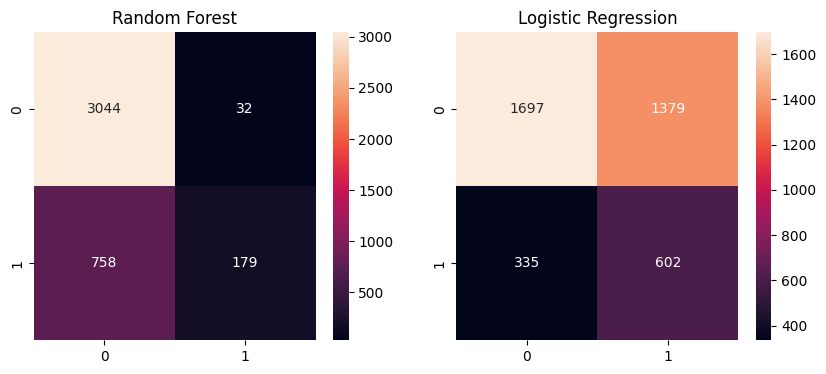

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

cm_rf = confusion_matrix(y_test_c, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", ax=axes[0])
axes[0].set_title("Random Forest")

cm_lr = confusion_matrix(y_test_c, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Logistic Regression")

plt.savefig("../reports/figures/matriz_confusion_RF_LR.png", dpi=150)


plt.show()

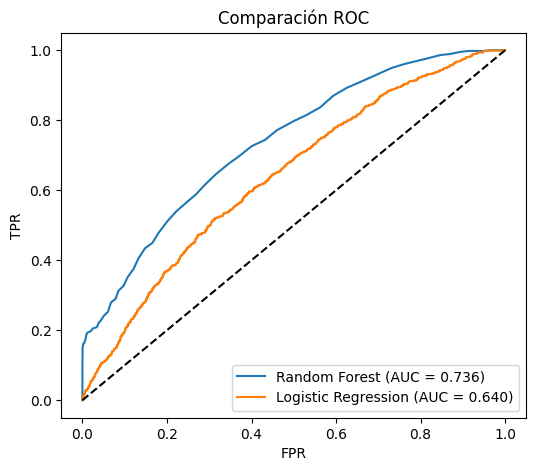

In [6]:
fpr_rf, tpr_rf, _ = roc_curve(y_test_c, y_proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test_c, y_proba_lr)

auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot([0,1],[0,1],"k--")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Comparación ROC")
plt.legend()
plt.savefig("../reports/figures/roc.png", dpi=150)

plt.show()

In [7]:
import pandas as pd
import yaml

with open("../config/config.yaml") as f:
    config = yaml.safe_load(f)

df_feat = pd.read_csv("../data/processed/datos_limpios.csv")

print("df_feat cargado:", df_feat.shape)

df_feat cargado: (20063, 34)


In [12]:
df_model = df_feat.copy()

df_model = df_model.drop(columns=[
    "Artist", "Track",
    "Stream", "Views", "Likes", "Comments"
    "engagement_rate", "log_Views", "log_Likes", "log_Comments", "log_Stream"

], errors="ignore")

df_model = df_model.dropna()

In [13]:
from pycaret.classification import *

clf = setup(
    data=df_model,
    target="viral",
    session_id=42
)

,Description,Value
0,Session id,42
1,Target,viral
2,Target type,Binary
3,Original data shape,"(19093, 25)"
4,Transformed data shape,"(19093, 25)"
5,Transformed train set shape,"(13365, 25)"
6,Transformed test set shape,"(5728, 25)"
7,Numeric features,17
8,Categorical features,7
9,Preprocess,True


In [14]:
from pycaret.classification import load_model

final_model = load_model("best_pycaret_model")

print("Modelo cargado correctamente")

Transformation Pipeline and Model Successfully Loaded
Modelo cargado correctamente


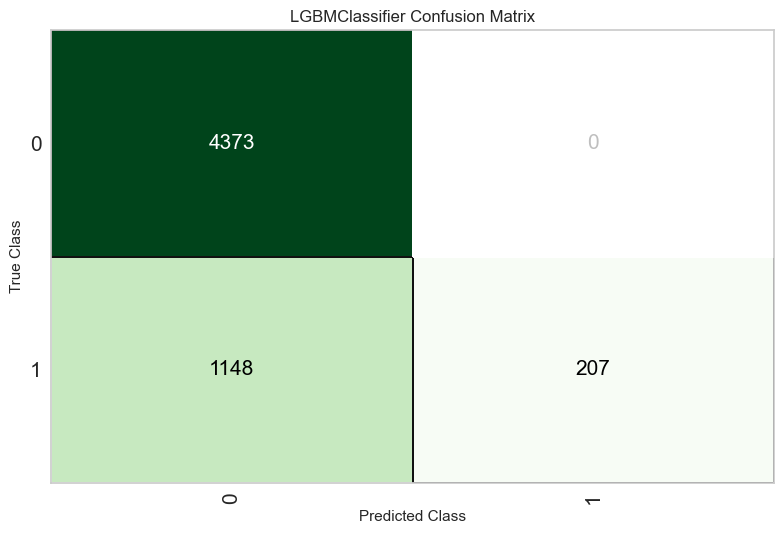

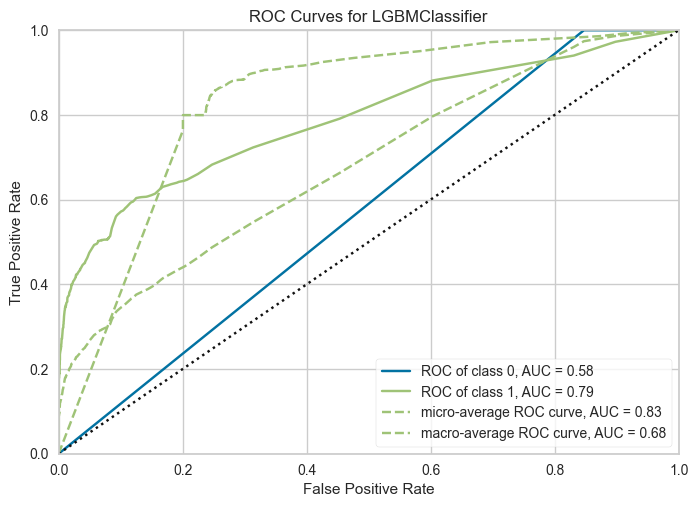

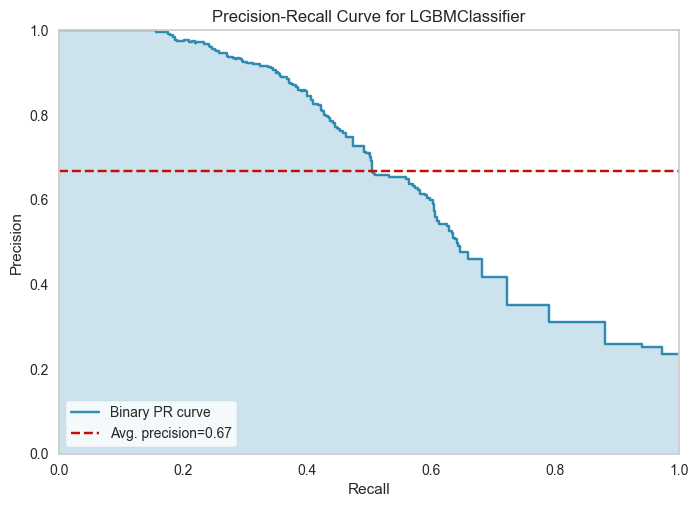

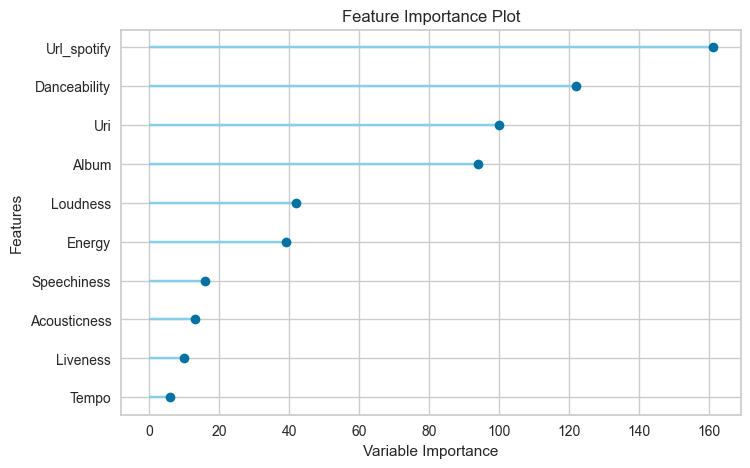

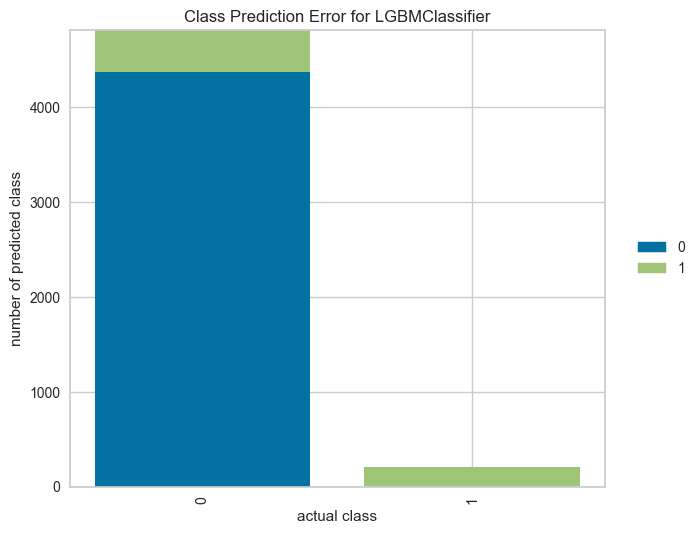

<Figure size 800x550 with 0 Axes>

In [15]:
plot_model(final_model, plot='confusion_matrix')
plot_model(final_model, plot='auc')
plot_model(final_model, plot='pr')            
plot_model(final_model, plot='feature')
plot_model(final_model, plot='error')

plt.savefig("../reports/figures/LGBM.png", dpi=150)
